# 01 - EDA et Nettoyage

Analyse exploratoire des données (EDA) et nettoyage du jeu de données `data/raw/car-price.csv`.

## 1. Import des bibliothèques

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
import os

os.makedirs('../reports/pre-cleaning', exist_ok=True)
os.makedirs('../reports/post-processing', exist_ok=True)


## 2. Chargement des données

In [61]:
df = pd.read_csv("../data/raw/car-price.csv").reset_index()
df.head()

,index,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          4340 non-null   int64  
 1   name           4340 non-null   str    
 2   year           4297 non-null   float64
 3   selling_price  4340 non-null   int64  
 4   km_driven      4167 non-null   float64
 5   fuel           4254 non-null   str    
 6   seller_type    4275 non-null   str    
 7   transmission   4340 non-null   str    
 8   owner          4254 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 548.6 KB


In [63]:
df.describe()

,index,year,selling_price,km_driven
count,4340.000000,4297.000000,4.340000e+03,4167.000000
mean,2169.500000,2013.087736,5.041273e+05,66237.198224
std,1252.994413,4.219918,5.785487e+05,46635.456187
min,0.000000,1992.000000,2.000000e+04,1.000000
25%,1084.750000,2011.000000,2.087498e+05,35000.000000
50%,2169.500000,2014.000000,3.500000e+05,60000.000000
75%,3254.250000,2016.000000,6.000000e+05,90000.000000
max,4339.000000,2020.000000,8.900000e+06,806599.000000


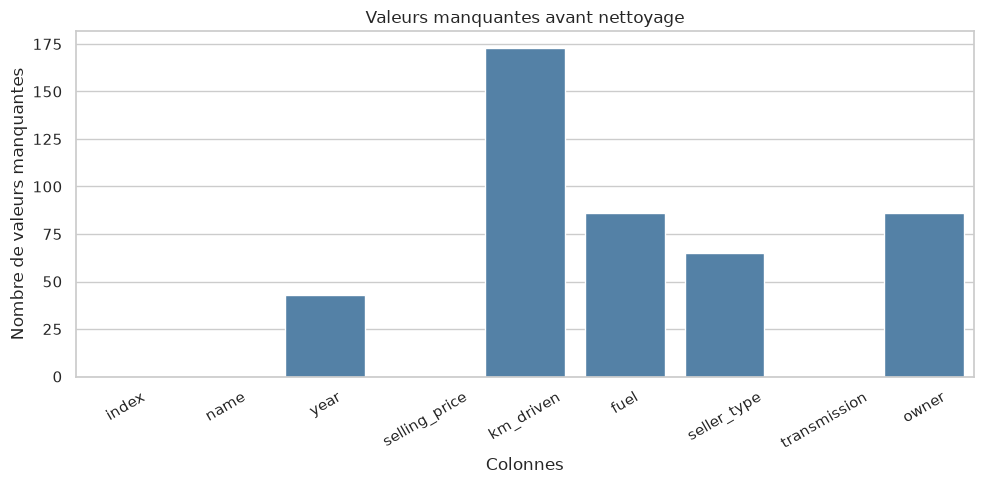

In [64]:
missing_values = df.isna().sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values, color='steelblue')
plt.title('Valeurs manquantes avant nettoyage')
plt.xlabel('Colonnes')
plt.ylabel('Nombre de valeurs manquantes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/pre-cleaning/missing_values_raw.png')
plt.show()


## 3. Nettoyage des données

### 3.1 Suppression des doublons

In [65]:
nb_dup = df.duplicated().sum()
if nb_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"{nb_dup} de doublons dropped")
else:
    print("aucun doublons trouvés")

aucun doublons trouvés


### 3.2 Gestion des valeurs nulles

In [66]:
# valeur manquante par colonne
print(df.isnull().sum()) 

# ligne avec nan 
ligne_avec_nan = df[df.isnull().any(axis=1)]
# ligne_avec_nan (verification post_traitement done)

index              0
name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64


### 3.3 imputation par mediane


In [67]:
mediane_year = df['year'].median()
df['year'] = df['year'].fillna(mediane_year)

medianne_km_driven = df['km_driven'].median()
df['km_driven'] = df['km_driven'].fillna(medianne_km_driven)

### 3.4 imputation par mode

In [68]:
# pour les colonnes textuels ou catégoriels

fuel_mode = df['fuel'].mode()[0]
df['fuel'] = df['fuel'].fillna(fuel_mode)

seller_type_mode = df['seller_type'].mode()[0]
df['seller_type'] = df['seller_type'].fillna(seller_type_mode)

owner_mode = df['owner'].mode()[0]
df['owner'] = df['owner'].fillna(owner_mode)

### 3.5 Vérification post-traitement qu'il reste 0 valeur manquante dans le dataframe.

## 4. Visualisation (EDA)

### 4.1 Distribution de `selling_price` et `km_driven`

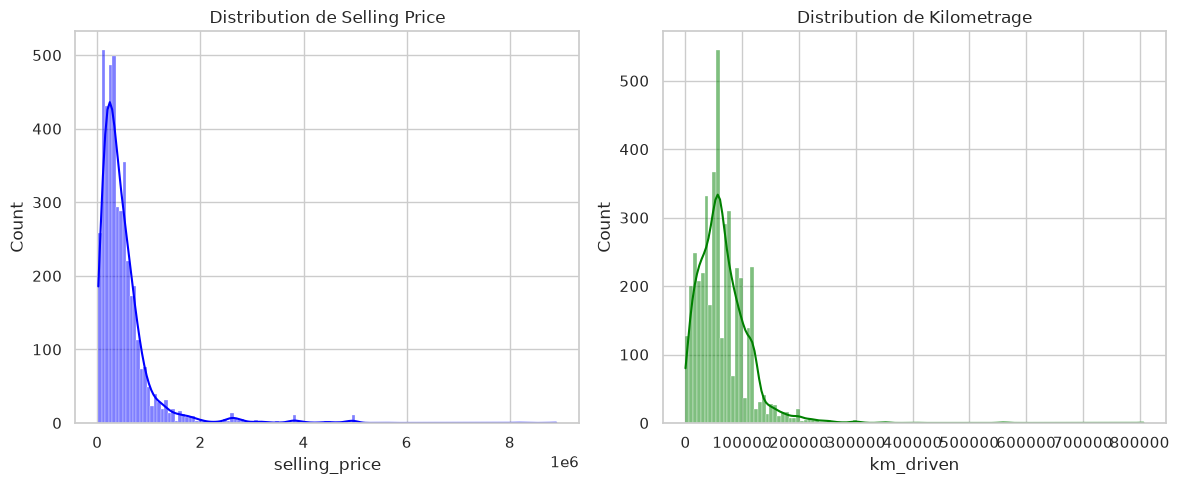

In [69]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['selling_price'], kde=True, color='blue')
plt.title('Distribution de Selling Price')

plt.subplot(1, 2, 2)
sns.histplot(df['km_driven'], kde=True, color='green')
plt.title('Distribution de Kilometrage')

plt.tight_layout()
plt.savefig('../reports/pre-cleaning/distributions_raw.png')
plt.show()

### 4.2 Matrice de corrélation

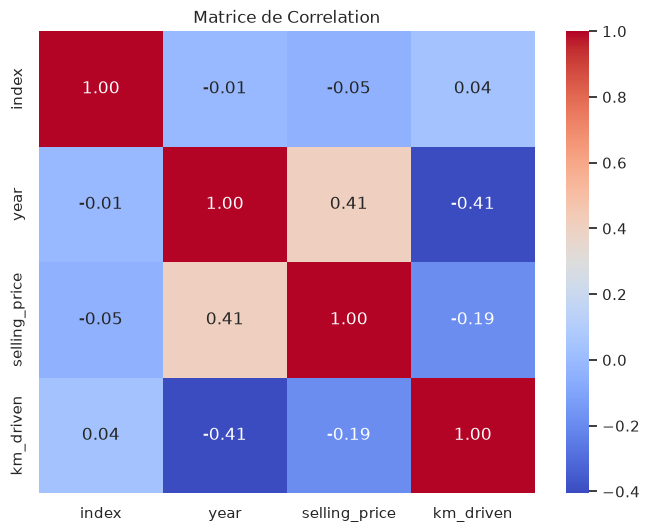

In [70]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Correlation')
plt.savefig('../reports/pre-cleaning/correlation_raw.png')
plt.show()

### 4.3 Pairplot

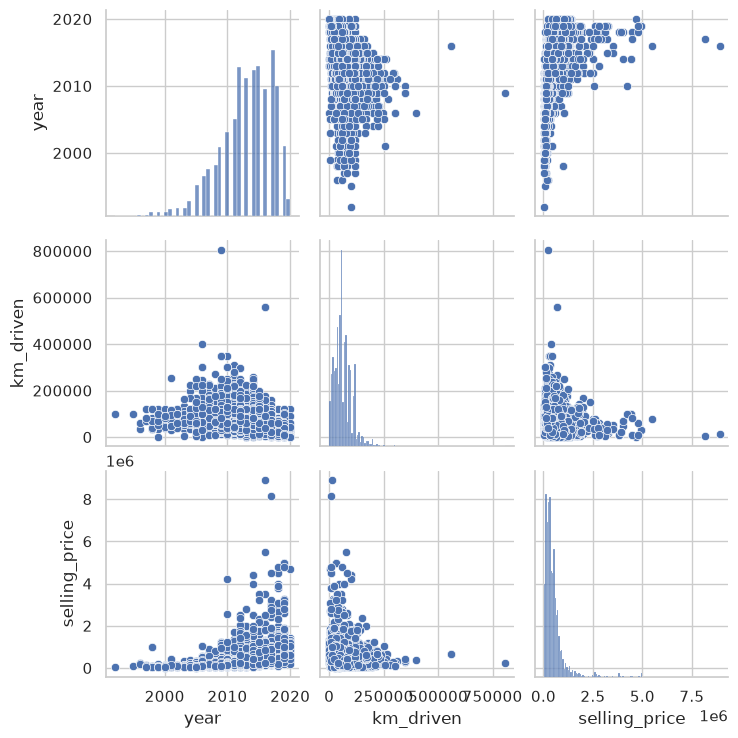

In [71]:
sns.pairplot(df[['year', 'km_driven', 'selling_price']])
plt.savefig('../reports/pre-cleaning/pairplots_raw.png')
plt.show()

#  5. Detection de valeurs aberrantes

### 5.1 Représentation des variables via des boîtes à moustaches (boxplots).

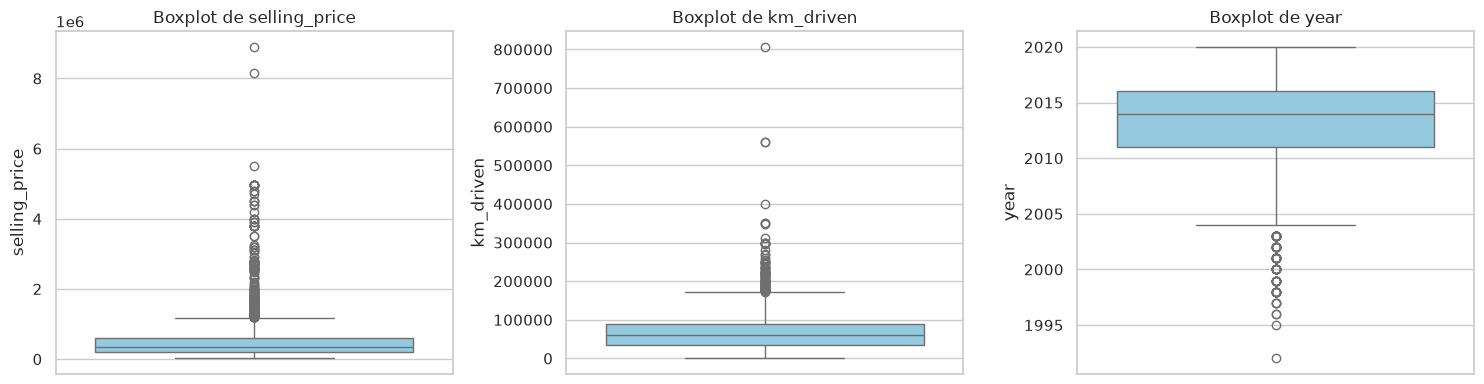

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
cols_outliers = ['selling_price', 'km_driven', 'year']

plt.figure(figsize=(15, 4))
for i, col in enumerate(cols_outliers, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.savefig('../reports/pre-cleaning/boxplots_raw.png')
plt.show()


### 5.2 Application d'une méthode de détection (Méthode IQR ou Z-score > 3).

In [73]:
def detect_outliers_iqr(dataFrame, column):
    Q1  =dataFrame[column].quantile(0.25)
    Q3  =dataFrame[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5  * IQR
    upper_bound = Q3 + 1.5  * IQR

    outliers = dataFrame[(dataFrame[column] < lower_bound) | (dataFrame[column] > upper_bound)]
    print(f"---------- {column} ----------")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Borne inférieure: {lower_bound:.2f}, Borne supérieure: {upper_bound:.2f}")
    print(f"Nombre d'outliers détectés : {len(outliers)} ({len(outliers)/len(dataFrame)*100:.2f}%)\n")
    
    return lower_bound, upper_bound

### 5.3 Analyse des cas limites et rédaction d'une justification pour chaque action (conservation, correction ou suppression).

In [74]:
bornes = {}

for col in cols_outliers:
    bornes[col] = detect_outliers_iqr(df, col)
print(bornes)

# ==============================================================================
# JUSTIFICATION DU TRAITEMENT DES OUTLIERS
# ==============================================================================

# 1. selling_price (Variable Cible)
# - Analyse       : Les prix très élevés désignent des véhicules de luxe ou récents.
# - Action        : Plafonnement (Capping) à la borne haute.
# - Justification : Conserve les lignes d'entrée sans supprimer les voitures chères, 
#                   évitant ainsi de biaiser l'apprentissage.

# 2. km_driven (Prédicteur)
# - Analyse       : Présence de kilométrages extrêmes ou d'erreurs de saisie (> 300 000 km).
# - Action        : Plafonnement (Capping) à la borne supérieure.
# - Justification : Élimine le bruit et évite de déformer la pente de régression.

# 3. year (Prédicteur)
# - Analyse       : Faible volume de véhicules très anciens aux prix très spécifiques.
# - Action        : Suppression des lignes où year < borne inférieure.
# - Justification : Recentre le modèle sur le marché principal des voitures récentes.

---------- selling_price ----------
Q1: 208749.75, Q3: 600000.00, IQR: 391250.25
Borne inférieure: -378125.62, Borne supérieure: 1186875.38
Nombre d'outliers détectés : 271 (6.24%)

---------- km_driven ----------
Q1: 35000.00, Q3: 90000.00, IQR: 55000.00
Borne inférieure: -47500.00, Borne supérieure: 172500.00
Nombre d'outliers détectés : 104 (2.40%)

---------- year ----------
Q1: 2011.00, Q3: 2016.00, IQR: 5.00
Borne inférieure: 2003.50, Borne supérieure: 2023.50
Nombre d'outliers détectés : 105 (2.42%)

{'selling_price': (np.float64(-378125.625), np.float64(1186875.375)), 'km_driven': (np.float64(-47500.0), np.float64(172500.0)), 'year': (np.float64(2003.5), np.float64(2023.5))}


### 5.4 Nettoyage du dataframe en appliquant les filtres définis.

In [75]:
_, borne_sup_price = bornes['selling_price']
_, borne_sup_km = bornes['km_driven']
borne_inf_year, _ = bornes['year']

df['selling_price'] = df['selling_price'].clip(upper=borne_sup_price)
df['km_driven'] = df['km_driven'].clip(upper=borne_sup_km)
df = df[df['year'] >= borne_inf_year].copy()


## 6. Justification des variables conservées

- `selling_price` est la variable cible : elle représente le prix que l'on cherche à prédire.
- `year` mesure l'ancienneté du véhicule et influence directement sa valeur.
- `km_driven` décrit l'usure et le kilométrage du véhicule.
- `fuel`, `seller_type`, `transmission` et `owner` bringent des informations utiles sur le type de moteur, le vendeur, la boîte de vitesses et l'historique du véhicule.
- La colonne `name` est supprimée car elle contient beaucoup de texte libre. La colonne `index` est également supprimée car elle ne représente aucune information métier.


In [76]:
df = df.drop(columns=['index'], errors='ignore')
df = df.drop(columns=['name'], errors='ignore')
df.head()


,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,2007.0,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,2007.0,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,2012.0,600000.0,100000.0,Diesel,Individual,Manual,First Owner
3,2017.0,250000.0,46000.0,Petrol,Individual,Manual,First Owner
4,2014.0,450000.0,141000.0,Diesel,Individual,Manual,Second Owner


## 7. Encodage des variables catégorielles

Les variables catégorielles sont transformées en colonnes binaires avec `get_dummies`. L'option `drop_first=True` évite de créer une colonne de référence pour chaque variable.

In [77]:
categorical_columns = ['fuel', 'seller_type', 'transmission', 'owner']
y = df['selling_price']
X = df.drop(columns=['selling_price'])

# Une seule colonne est conservée pour chaque variable catégorielle.
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True, dtype=int)
X.head()


,year,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007.0,70000.0,0,0,0,1,1,0,1,0,0,0,0
1,2007.0,50000.0,0,0,0,1,1,0,1,0,0,0,0
2,2012.0,100000.0,1,0,0,0,1,0,1,0,0,0,0
3,2017.0,46000.0,0,0,0,1,1,0,1,0,0,0,0
4,2014.0,141000.0,1,0,0,0,1,0,1,0,1,0,0


## 8. Séparation des données d'apprentissage et de test

Le dataset est séparé en 80 % pour l'apprentissage et 20 % pour le test avec une graine fixe afin de rendre le résultat reproductible.

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Train :', X_train.shape, y_train.shape)
print('Test  :', X_test.shape, y_test.shape)


Train : (3388, 13) (3388,)
Test  : (847, 13) (847,)


## 9. Standardisation des variables numériques

Les colonnes `year` et `km_driven` sont standardisées pour les ramener à une moyenne proche de 0 et un écart-type proche de 1. Les variables binaires ne sont pas standardisées.

In [79]:
from sklearn.preprocessing import StandardScaler

numeric_columns = ['year', 'km_driven']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Le scaler est ajusté uniquement sur les données d'apprentissage.
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

X_train_scaled.head()


,year,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
4168,0.688538,1.429968,1,0,0,0,1,0,1,0,0,0,0
4045,-1.184096,1.429968,1,0,0,0,1,0,1,0,0,0,1
3238,-0.381539,0.408986,0,0,0,1,1,0,1,0,0,0,0
3335,1.223577,-0.816193,0,0,0,1,1,0,1,0,0,0,0
227,0.956058,-1.122487,1,0,0,0,1,0,1,0,0,0,0


## 10. Visualisations après nettoyage et transformation

Les distributions, le pairplot et la matrice de corrélation sont recalculés sur les données nettoyées, encodées et standardisées.

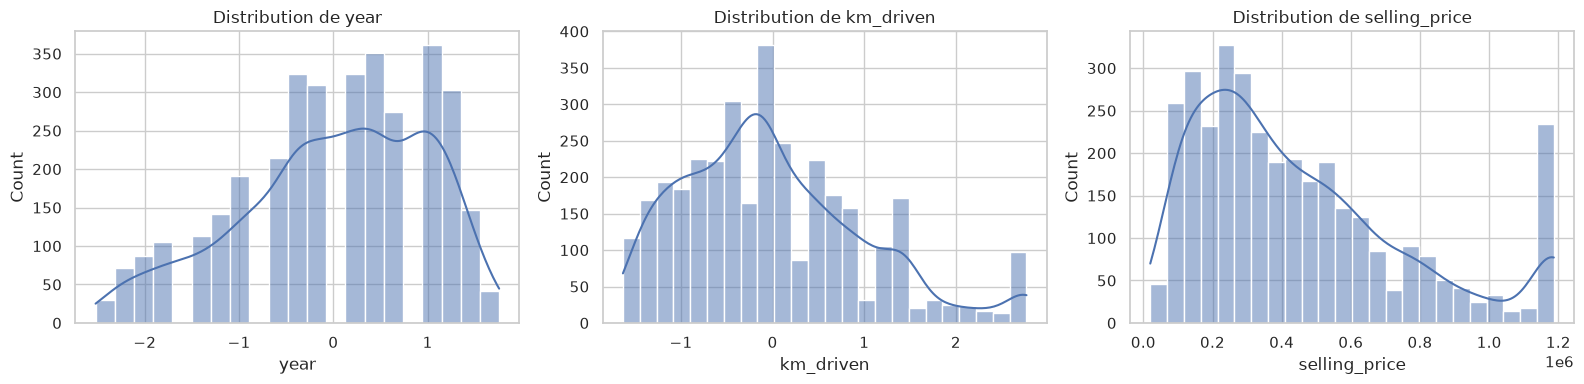

In [80]:
cleaned_data = X_train_scaled[numeric_columns].copy()
cleaned_data['selling_price'] = y_train

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ['year', 'km_driven', 'selling_price']):
    sns.histplot(cleaned_data[column], kde=True, ax=ax)
    ax.set_title(f'Distribution de {column}')

plt.tight_layout()
plt.savefig('../reports/post-processing/distributions_cleaned.png')
plt.show()


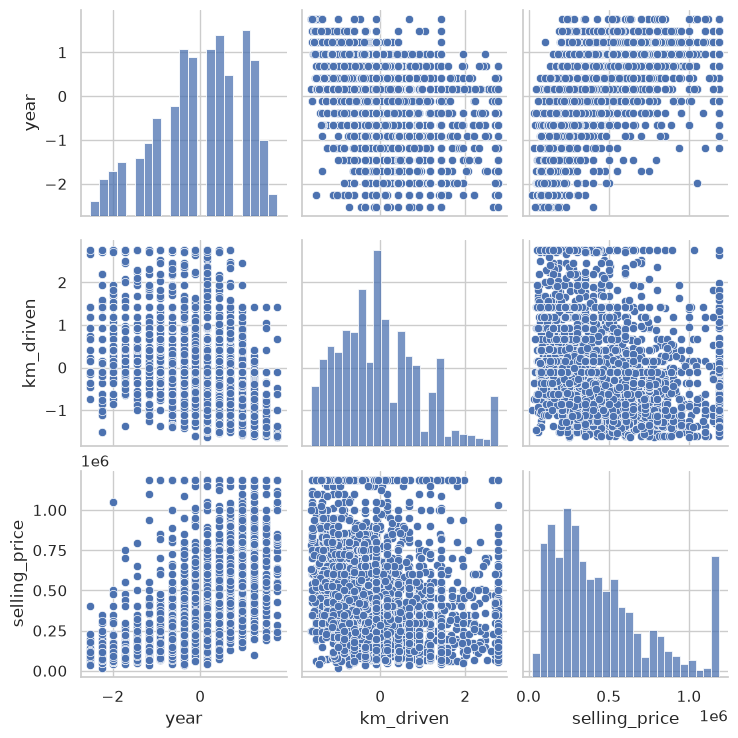

In [81]:
sns.pairplot(cleaned_data)
plt.savefig('../reports/post-processing/pairplots_cleaned.png')
plt.show()


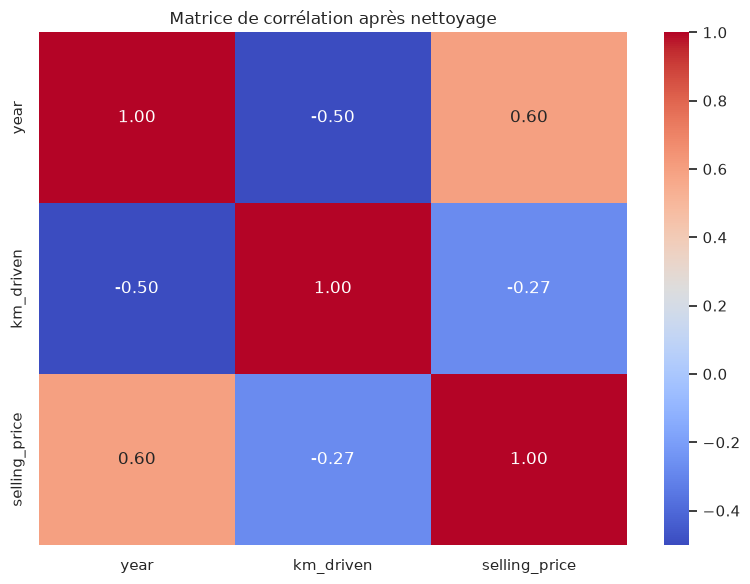

In [82]:
correlation_matrix = cleaned_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation après nettoyage')
plt.tight_layout()
plt.savefig('../reports/post-processing/correlation_cleaned.png')
plt.show()


# import processed data

In [83]:
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/cleaned_car_price.csv', index=True)
print("data imported with success")

data imported with success
